In [2]:
# ================================================================
# EXTRAÇÃO DE PARALELEPÍPEDO 3D + MOSAICO + HISTOGRAMA + GAUSSIANA
# ================================================================
#
# Este código pressupõe que:
#
#     imgFDK
#
# já exista e seja uma imagem 3D reconstruída pelo TIGRE.
#
# Estrutura:
#
#     imgFDK[z, y, x]
#
# Fluxo:
#
#     1) Escolher uma fatia Z
#     2) Desenhar um retângulo sobre a região de interesse
#     3) Obter Xmin, Xmax, Ymin, Ymax
#     4) Escolher Z inicial e Z final
#     5) Extrair o paralelepípedo
#     6) Visualizar várias fatias da ROI em mosaico
#     7) Gerar histograma dos valores CT
#     8) Ajustar uma Gaussiana
#     9) Obter μ e σ da região
#
# ================================================================

In [1]:
# Importar bibliotecas
import matplotlib.pyplot as plt
import matplotlib.font_manager as font_manager
from matplotlib.widgets import Slider
import numpy as np
import tigre
import tigre.algorithms as algs



import numpy as np
import matplotlib.pyplot as plt

from matplotlib.widgets import RectangleSelector
from scipy.optimize import curve_fit


In [2]:
# Carregar projeções
projs = np.load(
    "/mnt/d/Iniciacao_cientifica/head_phantom/imagens_raw2/sinoAula2.npz"
)

projs = projs["sino"]

projs_ln = -np.log(projs/1.0)

#%% Definir a geometria 
geo = tigre.geometry_default(high_resolution=True)

print("Projeções:", projs.shape)

Projeções: (719, 1024, 1024)


In [3]:
count = (projs_ln < 0).sum()
total = projs_ln.size
print(f'Projeções com valores negativos: {count} de {total} ({count/total:.2%})')

projs_ln [projs_ln < 0] = 0

Projeções com valores negativos: 45299903 de 753926144 (6.01%)


In [4]:
#%% Definir a geometria 
geo = tigre.geometry_default(high_resolution=True)

print("Projeções:", projs.shape)

Projeções: (719, 1024, 1024)


In [5]:
# ============================================================
# GEOMETRIA TIGRE
# ============================================================

geo = tigre.geometry_default(high_resolution=True)

# Distâncias
geo.DSD = 1150   # mm
geo.DSO = 1000   # mm



In [6]:
# Detector
geo.nDetector = np.array([1024, 1024])
geo.dDetector = np.array([0.3, 0.3])
geo.sDetector = (
    geo.nDetector * geo.dDetector
)

# Volume reconstruído
geo.nVoxel = np.array([384, 400, 400])
geo.sVoxel = np.array([240, 250, 250])
geo.dVoxel = (
    geo.sVoxel / geo.nVoxel
)

geo.accuracy = 0.5

In [7]:
angles = np.linspace(0, 360, 719, endpoint=False, dtype=np.float32)

In [8]:
# ================================================================
# 1. VERIFICAR A IMAGEM
# ================================================================

imgFDK = algs.fdk(projs_ln, geo, angles,filter="hann")



In [9]:
print("imgFDK:", imgFDK.shape)


print("========== INFORMAÇÕES DA RECONSTRUÇÃO ==========")

print("Shape imgFDK:")
print(imgFDK.shape)

print("\nValor mínimo:")
print(imgFDK.min())

print("\nValor máximo:")
print(imgFDK.max())

print("\nValor médio:")
print(imgFDK.mean())

imgFDK: (384, 400, 400)
========== INFORMAÇÕES DA RECONSTRUÇÃO ==========
Shape imgFDK:
(384, 400, 400)

Valor mínimo:
-0.010977794

Valor máximo:
0.04368807

Valor médio:
0.008484604


In [71]:
# Definindo ROI`s
#imgFDK[z, y, x]
#roi_agua = imgFDK [0:10, 650:750, 480:550]
#roi_ar = imgFDK [0:10, 852:922,60:130]

#roi_agua = imgFDK [200:300, 180:230, 180:220]
#roi_ar = imgFDK [200:300, 10:60, 20:60]
#roi_osso = imgFDK [378:388, 190:215, 180:220]

roi_agua = imgFDK [250:260, 185:210, 180:230]
roi_ar = imgFDK [94:104, 40:65, 20:70]
roi_osso = imgFDK [180:200, 190:210, 290:330]
roi_cerebro = imgFDK [120:140, 230:250, 140:190]
#roi_osso = imgFDK [375:377, 180:205, 180:230]


#mu_ar = np.mean(roi_ar)
#mu_agua = np.mean(roi_agua)
#mu_osso = np.mean(roi_osso)

#mu_agua_std = np.std(roi_agua)
#mu_ar_std = np.std(roi_ar)
#mu_osso_std = np.std(roi_osso)

#print("μ água =", mu_agua)
#print("μ ar =", mu_ar)
#print("μ osso =", mu_osso)

#print("Desvio padrão agua=", mu_agua_std)
#print("Desvio padrão ar=", mu_ar_std)
#print("Desvio padrão osso=", mu_osso_std)

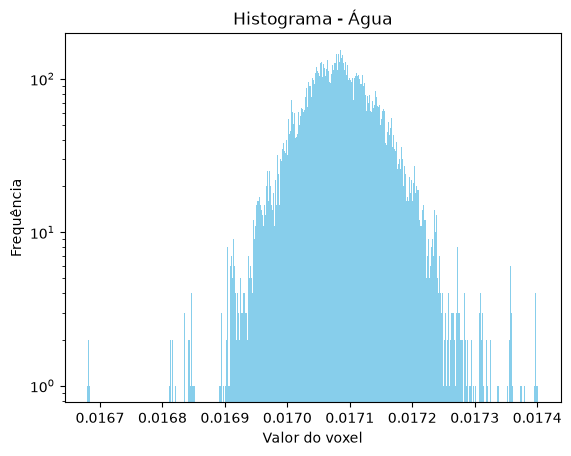

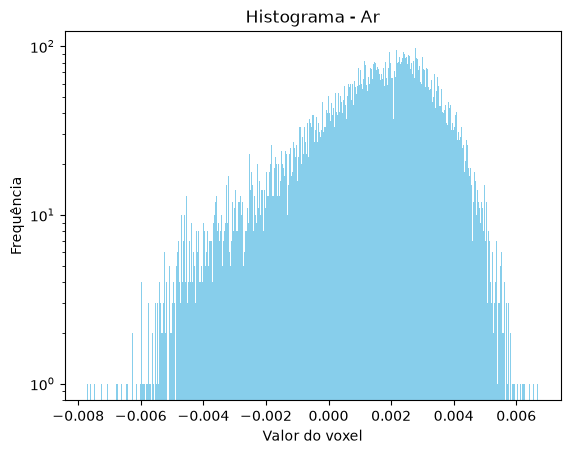

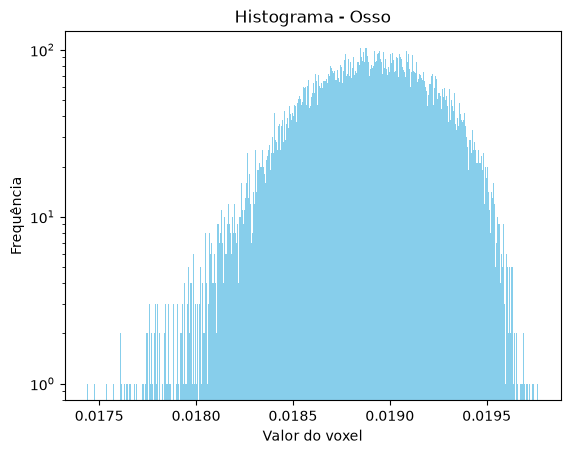

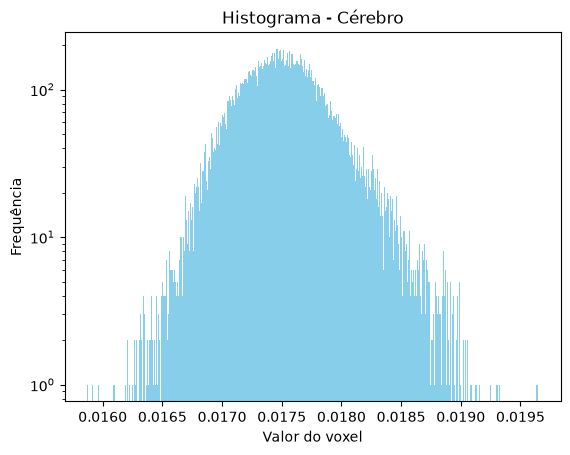

In [72]:
# ============================================================
# HISTOGRAMA DA ÁGUA
# ============================================================

fig = plt.figure()
ax = plt.axes()

ax.hist(
    roi_agua.flatten(),
    bins=512,
    color='skyblue',
    log=True
)

ax.set_xlabel('Valor do voxel')
ax.set_ylabel('Frequência')
ax.set_title('Histograma - Água')

plt.show()


# ============================================================
# HISTOGRAMA DA AR
# ============================================================

fig = plt.figure()
ax = plt.axes()

ax.hist(
    roi_ar.flatten(),
    bins=512,
    color='skyblue',
    log=True
)

ax.set_xlabel('Valor do voxel')
ax.set_ylabel('Frequência')
ax.set_title('Histograma - Ar')

plt.show()


# ============================================================
# HISTOGRAMA DA OSS0
# ============================================================

fig = plt.figure()
ax = plt.axes()

ax.hist(
    roi_osso.flatten(),
    bins=512,
    color='skyblue',
    log=True
)

ax.set_xlabel('Valor do voxel')
ax.set_ylabel('Frequência')
ax.set_title('Histograma - Osso')

plt.show()



# ============================================================
# HISTOGRAMA DO CÉREBRO
# ============================================================

fig = plt.figure()
ax = plt.axes()

ax.hist(
    roi_cerebro.flatten(),
    bins=512,
    color='skyblue',
    log=True
)

ax.set_xlabel('Valor do voxel')
ax.set_ylabel('Frequência')
ax.set_title('Histograma - Cérebro')

plt.show()



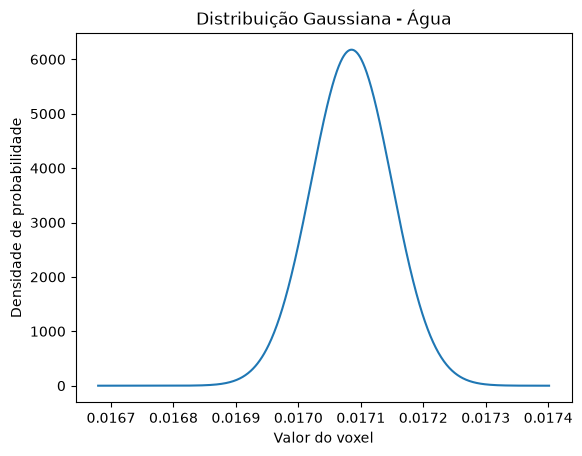

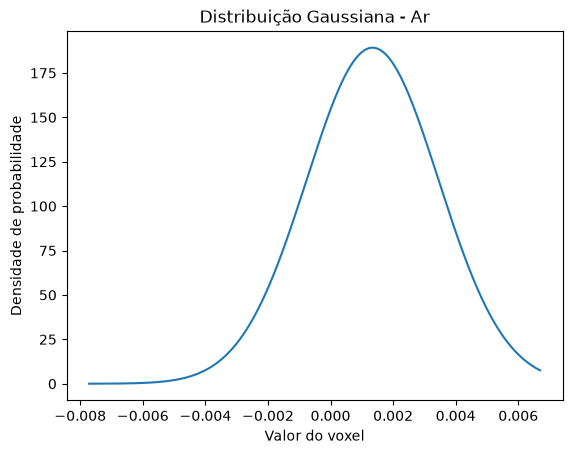

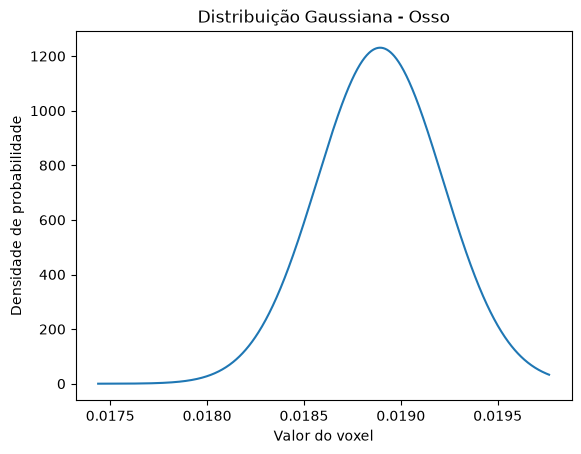

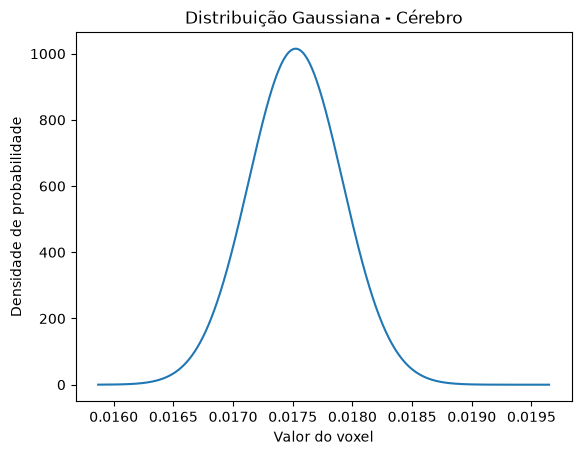

ÁGUA
μ = 0.017085103318095207
σ = 6.458493589889258e-05
AR
μ = 0.0013433425920084119
σ = 0.0021083636675029993
OSSO
μ = 0.01889307051897049
σ = 0.00032412775908596814
CÉREBRO
μ = 0.017524318769574165
σ = 0.000392988498788327


In [73]:
# ============================================================
# FUNÇÃO PARA GERAR A DISTRIBUIÇÃO GAUSSIANA
# ============================================================

def gaussiana(dados):

    # Transformar em vetor
    dados = dados.flatten()

    # Média
    mu = np.mean(dados)

    # Desvio padrão
    sigma = np.std(dados)

    # Eixo x
    x = np.linspace(
        dados.min(),
        dados.max(),
        1000
    )

    # Distribuição Gaussiana
    gauss = (
        1 / (sigma * np.sqrt(2 * np.pi))
        *
        np.exp(
            -((x - mu) ** 2) /
            (2 * sigma ** 2)
        )
    )

    return x, gauss, mu, sigma


# ============================================================
# GAUSSIANA - ÁGUA
# ============================================================

x_agua, g_agua, mu_agua, sigma_agua = gaussiana(roi_agua)

fig = plt.figure()
ax = plt.axes()

ax.plot(x_agua, g_agua)

ax.set_xlabel('Valor do voxel')
ax.set_ylabel('Densidade de probabilidade')
ax.set_title('Distribuição Gaussiana - Água')
plt.show()


# ============================================================
# GAUSSIANA - AR
# ============================================================

x_ar, g_ar, mu_ar, sigma_ar = gaussiana(roi_ar)

fig = plt.figure()
ax = plt.axes()

ax.plot(x_ar, g_ar)

ax.set_xlabel('Valor do voxel')
ax.set_ylabel('Densidade de probabilidade')
ax.set_title('Distribuição Gaussiana - Ar')
plt.show()


# ============================================================
# GAUSSIANA - AR
# ============================================================

x_osso, g_osso, mu_osso, sigma_osso = gaussiana(roi_osso)

fig = plt.figure()
ax = plt.axes()

ax.plot(x_osso, g_osso)

ax.set_xlabel('Valor do voxel')
ax.set_ylabel('Densidade de probabilidade')
ax.set_title('Distribuição Gaussiana - Osso')
plt.show()


# ============================================================
# GAUSSIANA - CÉREBRO
# ============================================================

x_cerebro, g_cerebro, mu_cerebro, sigma_cerebro = gaussiana(roi_cerebro)

fig = plt.figure()
ax = plt.axes()

ax.plot(x_cerebro, g_cerebro)

ax.set_xlabel('Valor do voxel')
ax.set_ylabel('Densidade de probabilidade')
ax.set_title('Distribuição Gaussiana - Cérebro')
plt.show()


# ============================================================
# MOSTRAR OS PARÂMETROS
# ============================================================

print("ÁGUA")
print(f"μ = {mu_agua}")
print(f"σ = {sigma_agua}")



print("AR")
print(f"μ = {mu_ar}")
print(f"σ = {sigma_ar}")

print("OSSO")
print(f"μ = {mu_osso}")
print(f"σ = {sigma_osso}")

print("CÉREBRO")
print(f"μ = {mu_cerebro}")
print(f"σ = {sigma_cerebro}")   


In [74]:
# Seleciona o melhor mu
roi_agua_HU = 1000 * ((roi_agua - mu_agua) / (mu_agua - mu_ar))
roi_ar_HU= 1000 * ((roi_ar   - mu_agua) / (mu_agua - mu_ar))
roi_osso_HU = 1000 * ((roi_osso - mu_agua) / (mu_agua - mu_ar))
roi_cerebro_HU = 1000 * ((roi_cerebro - mu_agua) / (mu_agua - mu_ar))


HU_agua = np.mean(roi_agua_HU)
HU_ar   = np.mean(roi_ar_HU)
HU_osso = np.mean(roi_osso_HU)
HU_cerebro = np.mean(roi_cerebro_HU)


print("HU água =", HU_agua)
print("HU ar   =", HU_ar)
print("HU osso =", HU_osso)
print("HU cérebro =", HU_cerebro)

HU água = -8.857422e-06
HU ar   = -1000.00006
HU osso = 114.85173
HU cérebro = 27.901344
